# Machine Learning LAB 2: Perceptrons

Course 2024/25: *F. Chiariotti*

The notebook contains a simple learning task over which we will implement **PERCEPTRON ALGORITHM**.

Complete all the **required code sections** and **answer all the questions**.

### IMPORTANT for the exam:

The functions you might be required to implement in the exam will have the same signature and parameters as the ones in the labs. 

## Classification of Stayed/Churned Customers

The Customer Churn table contains information on all 3,758 customers from a Telecommunications company in California in Q2 2022. Companies are naturally interested in churn, i.e., in which users are likely to switch to another company soon to get a better deal, and which are more loyal customers.

The dataset contains three features:
- **Tenure in Months**: Number of months the customer has stayed with the company
- **Monthly Charge**: The amount charged to the customer monthly
- **Age**: Customer's age

The aim of the task is to predict if a customer will churn or not based on the three features.

---

## Import all the necessary Python libraries and load the dataset

### The Dataset
The dataset is a `.csv` file containing three input features and a label. Here is an example of the first 4 rows of the dataset: 

<center>

Tenure in Months | Monthly Charge | Age | Customer Status |
| -----------------| ---------------|-----|-----------------|
| 9 | 65.6 | 37 | 0 |
| 9 | -4.0 | 46 | 0 |
| 4 | 73.9 | 50 | 1 |
| ... | ... | ... | ... |

</center>

Customer Status is 0 if the customer has stayed with the company and 1 if the customer has churned.

In [1]:
import numpy as np
import random as rnd
import pandas as pd
from matplotlib import pyplot as plt
from sklearn import linear_model, preprocessing
from sklearn.model_selection import train_test_split

np.random.seed(42)

def load_dataset(filename):
    data_train = pd.read_csv(filename)
    #permute the data
    data_train = data_train.sample(frac=1).reset_index(drop=True) # shuffle the data
    X = data_train.iloc[:, 0:3].values # Get first three columns as the input
    Y = data_train.iloc[:, 3].values # Get the fourth column as the label
    Y = 2*Y-1 # Make sure labels are -1 or 1 (0 --> -1, 1 --> 1)
    return X,Y

# Load the dataset
X, Y = load_dataset('telecom_customer_churn_cleaned.csv')
#X, Y = load_dataset('data/telecom_customer_churn_cleaned.csv')

We are going to differentiate (classify) between **class "1" (churned)** and **class "-1" (stayed)**

1. **`.iloc` and `.values`**:
   - **`.iloc`**: This is a pandas method that allows integer-based indexing. In this case, it's used to select specific columns or rows by their integer location (like `0`, `1`, `2`, etc.).
   - **`.values`**: This attribute converts the DataFrame into a NumPy array. After selecting certain rows/columns with `.iloc`, adding `.values` outputs these selections as arrays instead of pandas DataFrame or Series objects.

   Specifically:
   - `X = data_train.iloc[:, 0:3].values`: Selects the first three columns (indices `0`, `1`, and `2`) as input features for the model and returns them as a NumPy array.
   - `Y = data_train.iloc[:, 3].values`: Selects the fourth column (index `3`) as the label, also as a NumPy array.

2. **Data Shuffling** (`data_train.sample(frac=1).reset_index(drop=True)`):
   - `data_train.sample(frac=1)`: `sample` with `frac=1` takes a random sample of all the rows in `data_train`, effectively shuffling the dataset.
   - `.reset_index(drop=True)`: After shuffling, the original index is discarded, and a new sequential index is assigned from `0` to the end. This prevents the old index from becoming a new column in the dataset.

3. **Transforming Labels** (`Y = 2*Y - 1`):
   - This step maps labels from `(0, 1)` to `(-1, 1)`. If `Y` contains labels `0` and `1`, multiplying by `2` and then subtracting `1` converts them: `0` becomes `-1`, and `1` stays `1`.

In summary, `.iloc[:, 0:3].values` and `.iloc[:, 3].values` select the features and labels as NumPy arrays, and the shuffle function ensures the data order is randomized for training. The label transformation is useful for algorithms that expect labels in `{-1, 1}` form.

## Divide the data into training and test sets

In [2]:
# Compute the splits
print(np.shape(X))
m_training = int(0.75*X.shape[0])

# m_test is the number of samples in the test set (total-training)
m_test =  X.shape[0] - m_training
X_training =  X[:m_training]
Y_training =  Y[:m_training]
X_test =   X[m_training:]
Y_test =  Y[m_training:]

print("Number of samples in the train set:", X_training.shape[0])
print("Number of samples in the test set:", X_test.shape[0])
print("Number of churned users in test:", np.sum(Y_test==-1))
print("Number of loyal users in test:", np.sum(Y_test==1))

# Standardize the input matrix
# The transformation is computed on training data and then used on all the 3 sets
scaler = preprocessing.StandardScaler().fit(X_training) 

np.set_printoptions(suppress=True) # sets to zero floating point numbers < min_float_eps
X_training =  scaler.transform(X_training)
print ("Mean of the training input data:", X_training.mean(axis=0))
print ("Std of the training input data:",X_training.std(axis=0))

X_test =  scaler.transform(X_test)
print ("Mean of the test input data:", X_test.mean(axis=0))
print ("Std of the test input data:", X_test.std(axis=0))
#for training and test we won't have exactly zero mean and one standard deviation 'cause they're not the full distribution

(3757, 3)
Number of samples in the train set: 2817
Number of samples in the test set: 940
Number of churned users in test: 465
Number of loyal users in test: 475
Mean of the training input data: [ 0. -0. -0.]
Std of the training input data: [1. 1. 1.]
Mean of the test input data: [ 0.0134851   0.04850383 -0.0433016 ]
Std of the test input data: [1.00014294 1.00683022 1.02078989]


This code standardizes the input data by ensuring that each feature (column) has a mean of 0 and a standard deviation of 1. Here’s a step-by-step breakdown:

1. **Standardization** (`StandardScaler().fit(X_training)`):
   - `StandardScaler` is used to standardize features by removing the mean and scaling to unit variance. This is a common preprocessing step for many machine learning algorithms, as it helps them converge more quickly and improves model performance.
   - `scaler = preprocessing.StandardScaler().fit(X_training)`: This line calculates the mean and standard deviation for each feature in the `X_training` data and stores them in `scaler`. These values will be used to transform both the training data and any other data in a consistent way.

2. **Transform Training Data** (`scaler.transform(X_training)`):
   - `X_training = scaler.transform(X_training)`: This applies the transformation to the training data, using the mean and standard deviation computed in the previous step. Each feature in `X_training` is centered around 0 and scaled to have a standard deviation of 1.

3. **Display Statistics for Training Data**:
   - `X_training.mean(axis=0)` and `X_training.std(axis=0)` calculate the mean and standard deviation for each feature (column) in the transformed training data and print the results.
   - After transformation, you should see values close to 0 for the mean and 1 for the standard deviation, confirming that the data has been standardized.

4. **Transform Test Data Using the Same Scaling** (`scaler.transform(X_test)`):
   - `X_test = scaler.transform(X_test)`: This applies the same transformation (computed on `X_training`) to the test set `X_test`. The idea is to use the same scaling parameters as the training data to ensure consistency across datasets.
   - This helps maintain the distribution of the test data relative to the training data.

5. **Display Statistics for Test Data**:
   - Similarly, the mean and standard deviation for each feature in `X_test` are printed. Due to standardization based on `X_training`, the test data may not have an exact mean of 0 and a standard deviation of 1, but it should be close.

6. **Suppress Small Floating-Point Numbers**:
   - `np.set_printoptions(suppress=True)`: This prevents Python from printing very small floating-point numbers in scientific notation (like `1e-8`). Instead, numbers close to zero are printed as `0.0`, improving readability.

In summary, this code fits a standardization transformation on the training data and then applies it to both the training and test sets to ensure that both have a similar feature distribution. This step is critical for many models that expect inputs to be on a similar scale.

We will use **homogeneous coordinates** to describe all the coefficients of the model.

_Hint:_ The conversion can be performed with the function $hstack$ in $numpy$.

In [3]:
def to_homogeneous(X_training, X_test):
    # TODO: Transform the input into homogeneous coordinates
    Xh_training = np.hstack([np.ones((X_training.shape[0], 1)), X_training]) #Stack arrays in sequence horizontally (column wise).
                        #This is equivalent to concatenation along the second axis, except for 1-D arrays where it concatenates along the first axis.
    Xh_test = np.hstack([np.ones((X_test.shape[0], 1)), X_test])
    return Xh_training, Xh_test

Using np.hstack or np.concatenate(..., axis=1) adds a new column along the second axis (axis 1). This inserts the column of 1s at the start of each row in X_training and X_test, expanding the arrays horizontally. 
NOTICE: concatenation can add elements either at the beginning or the end, depending on how you arrange the arrays in the function.

In [4]:
# convert to homogeneous coordinates using the function above
X_training, X_test = to_homogeneous(X_training, X_test)
print("Training set in homogeneous coordinates:")
print(X_training[:10])


Training set in homogeneous coordinates:
[[ 1.          1.2361321   0.87798477 -0.16001986]
 [ 1.          0.10884685  0.4417593   1.37363294]
 [ 1.          1.69539647 -1.57223186 -0.04204657]
 [ 1.          0.15059816 -0.93544295  0.84275312]
 [ 1.          0.56811122 -0.38890759 -0.57292638]
 [ 1.         -0.39216881 -1.41010975 -0.39596645]
 [ 1.         -1.0184384  -1.53880462 -1.04481955]
 [ 1.         -0.35041751 -0.71649454  0.72477983]
 [ 1.         -1.18544362 -1.45857925  0.4298466 ]
 [ 1.          1.44488863 -1.4385229  -0.16001986]]


## Deterministic perceptron

Now **complete** the function *perceptron*. <br>
The **perceptron** algorithm **does not terminate** if the **data** is not **linearly separable**, therefore your implementation should **terminate** if it **reached the termination** condition seen in class **or** if a **maximum number of iterations** have already been run, where one **iteration** corresponds to **one update of the perceptron weights**. In case the **termination** is reached **because** the **maximum** number of **iterations** have been completed, the implementation should **return the best model** seen throughout.

The current version of the perceptron is **deterministic**: we use a fixed rule to decide which sample should be considered (e.g., the one with the lowest index).

The input parameters to pass are:
- $X$: the matrix of input features, one row for each sample
- $Y$: the vector of labels for the input features matrix X
- $max\_num\_iterations$: the maximum number of iterations for running the perceptron

The output values are:
- $best\_w$: the vector with the coefficients of the best model (or the latest, if the termination condition is reached)
- $best\_error$: the *fraction* of misclassified samples for the best model

In [46]:
"""def count_errors(current_w, X, Y):
     # This function:
    # -computes the number of misclassified samples
    # -returns the indexes of all misclassified samples
    # -if there are no misclassified samples, returns -1 as index
    # TODO: write the function
    n = 0
    index = []
    for i in range(len(X)):
        if Y[i] * np.dot(current_w, X[i]) <= 0:
            n += 1
            index.append(i)
    if n == 0:
        return 0, -1
    return n, index """

#Another way to do this was: 
def count_errors(current_w, X, Y):
    #Find all indices which have a different sign from the corresponding labels
    index = np.nonzero(np.sign(np.dot(X, current_w)) - Y)[0]
    n = np.array(index).shape[0]
    if (n == 0):
         #There are no misclassified samples
        return 0, -1
    return n, index 

def perceptron_fixed_update(current_w, X, Y):
    # TODO: write the perceptron update function
    new_w = current_w
    n, idx = count_errors(current_w, X, Y)
    # Choose the first misclassified sample
    if (n > 0):
        new_w = current_w + Y[idx[0]] * X[idx[0],:] #remember here that X is a matrix with three columns. You want to consider here one row at a time as a point xi
    return new_w

def perceptron_no_randomization(X, Y, max_num_iterations):
    # TODO: write the perceptron main loop
    # The perceptron should run for up to max_num_iterations, or stop if it finds a solution with ERM=0
    
    # Initialize some support variables
    num_samples = X.shape[0] #number of rows of X (basically the cardinality of the training set)
    num_iter = 0
    
    # Initialize the weights of the algorith with w=0
    curr_w = np.zeros(X.shape[1])

    # Compute the number of misclassified samples and the indexes
    num_misclassified, index_misclassified = count_errors(curr_w, X, Y)
    
    # Initialize the best model
    best_error = num_misclassified / num_samples
    best_w = curr_w.copy() #take a copy so you don't directly modify curr_w
    
    # Main loop: continue until all samples correctly classified or max # iterations reached
    # Remember: if no errors were found, index_misclassified = -1
    while num_misclassified != 0 and num_iter < max_num_iterations:
        # Update the perceptron
        curr_w = perceptron_fixed_update(curr_w, X, Y)
        # Find the new error
        num_misclassified, index_misclassified = count_errors(curr_w, X, Y)
        if num_misclassified / num_samples < best_error:
            best_error = num_misclassified / num_samples
            best_w = curr_w.copy()
        num_iter += 1
    
    return best_w, best_error


**NOTICE:**
If you omit .copy(), the line:

python
Copy code
best_w = curr_w
will make best_w a reference to the same array as curr_w. As a result:

Whenever you update curr_w, it will also modify best_w because both variables will point to the same memory location.
Consequently, best_w will always reflect the current state of curr_w, not the state when the best model was found. This means the algorithm will fail to correctly track the best solution it encountered during training.

Now we use the implementation above of the perceptron to learn a model from the training data using 30 iterations and print the error of the best model we have found.

In [47]:
w_found, error = perceptron_no_randomization(X_training,Y_training, 30)
print("Training Error of perceptron (30 iterations): " + str(error))
w_found2, error2 = perceptron_no_randomization(X_training,Y_training, 100)
print("Training Error of perceptron (100 iterations): " + str(error2))

Training Error of perceptron (30 iterations): 0.24565140220092296
Training Error of perceptron (100 iterations): 0.24565140220092296


Now use the best model $w\_found$ to **predict the labels for the test dataset** and print the fraction of misclassified samples in the test set (the test error that is an estimate of the true loss).

In [48]:
def loss_estimate(w,X,Y):
    # Estimate the test loss
    err,_ = count_errors(w, X, Y) #,_ syntax is used to unpack the result of a function call when you are only interested in certain elements of the returned values and want to ignore the others.
    t_loss_estimate = err/len(Y)
    return t_loss_estimate

true_loss_estimate =  loss_estimate(w_found, X_test, Y_test)       # Error rate on the test set
true_loss_estimate2 =  loss_estimate(w_found2, X_test, Y_test) 
    
print("Test Error of perceptron (30 iterations): " + str(true_loss_estimate))
print("Test Error of perceptron (100 iterations): " + str(true_loss_estimate2))

Test Error of perceptron (30 iterations): 0.25
Test Error of perceptron (100 iterations): 0.25


### Randomized perceptron

Implement the correct randomized version of the perceptron such that at each iteration the algorithm picks a random misclassified sample and updates the weights using that sample. The functions will be very similar, except for some minor details.

In [49]:
def perceptron_randomized_update(current_w, X, Y):
    # TODO: write the perceptron update function
    new_w=current_w
    n, idx = count_errors(current_w, X, Y)
    # Choose a random misclassified sample
    if (n > 0):
        chosen = rnd.sample(sorted(idx), 1)[0]
        new_w = current_w + Y[chosen] * X[chosen,:]
    return new_w

def perceptron_with_randomization(X, Y, max_num_iterations):
    # TODO: write the perceptron main loop
    # The perceptron should run for up to max_num_iterations, or stop if it finds a solution with ERM=0
    
    # Initialize some support variables
    num_samples = X.shape[0]
    num_iter = 0
    
    # Initialize the weights of the algorith with w=0
    curr_w = np.zeros(X.shape[1])

    # Compute the number of misclassified samples and the indexes
    num_misclassified, index_misclassified = count_errors(curr_w, X, Y)
    # Initialize the best model
    best_error = num_misclassified / num_samples
    best_w = curr_w.copy()
    
    # Main loop: continue until all samples correctly classified or max # iterations reached
    # Remember: if no errors were found, index_misclassified = -1
    while num_misclassified != 0 and num_iter < max_num_iterations:
        # Update the perceptron
        curr_w = perceptron_randomized_update(curr_w, X, Y)
        # Find the new error
        num_misclassified, index_misclassified = count_errors(curr_w, X, Y)
        if num_misclassified / num_samples < best_error:
            best_error = num_misclassified / num_samples
            best_w = curr_w.copy()
        num_iter += 1
    return best_w, best_error

Now test the correct version of the perceptron using 30 iterations and print the error of the best model we have found.

In [50]:
# Now run the perceptron for 30 iterations
w_found, error = perceptron_with_randomization(X_training, Y_training, 30)
w_found2, error2 = perceptron_with_randomization(X_training, Y_training, 100)
print("Training Error of perceptron (30 iterations): " + str(error))
print("Training Error of perceptron (100 iterations): " + str(error2))

true_loss_estimate =  loss_estimate(w_found, X_test, Y_test)       # Error rate on the test set
true_loss_estimate2 =  loss_estimate(w_found2, X_test, Y_test) 

print("Test Error of perceptron (30 iterations): " + str(true_loss_estimate))
print("Test Error of perceptron (100 iterations): " + str(true_loss_estimate2))

Training Error of perceptron (30 iterations): 0.25914093006744765
Training Error of perceptron (100 iterations): 0.24849130280440185
Test Error of perceptron (30 iterations): 0.26382978723404255
Test Error of perceptron (100 iterations): 0.2531914893617021


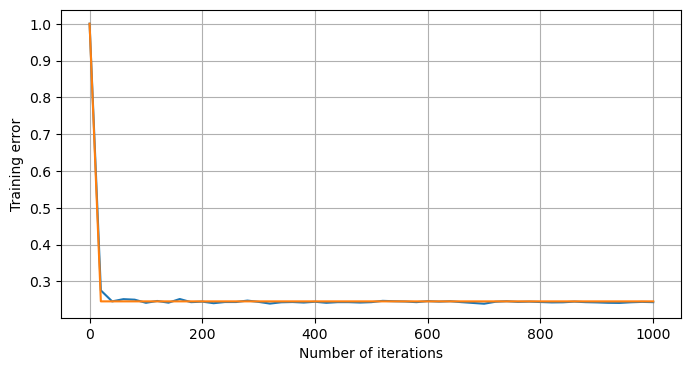

In [53]:
# TODO Plot the loss with respect to the number of iterations (up to 1000)
plt.figure(figsize=(8,4))

num_iters = np.arange(0, 1001,20)
errors_rand = []
errors_det = []

for num_iter in num_iters:
    _, error_rand = perceptron_with_randomization(X_training, Y_training, num_iter)
    _, error_det = perceptron_no_randomization(X_training, Y_training, num_iter)
    errors_rand.append(error_rand)
    errors_det.append(error_det)

plt.plot(num_iters, errors_rand, label='Random')
plt.plot(num_iters, errors_det, label='Deterministic')
plt.xlabel('Number of iterations')
plt.ylabel('Training error')
plt.grid()
plt.show()

**COMMENT TO THIS:**
Usually the training error could be higher for the deterministic case because the algorithm could get stuck in some local minima. 